# 06 — Linearity Analysis

Does coupling efficiency depend on the vibration **amplitude**? Dedicated
mono-frequency test signal: 8 frequencies (5–400 Hz), each a 3.5 s segment
with a 0→1 linear amplitude ramp followed by a 0.5 s fade.

Per segment (`analysis.linearity_qc`): bandpass ± 5 Hz → integrate (÷ iω) →
cable elongation δxₗ (arc-length) and reference δL (chord-projected shaker) /
Δu_ends (endpoints) → η(t); the **Hilbert envelope** |H(δL)|(t) is the
instantaneous drive amplitude the η values are plotted against.

| § | Content |
|---|---|
| 1 | Loading & geometry |
| 2 | Raw signal overview |
| 3 | Run the segment analysis |
| 4 | η(t) per frequency + η vs amplitude |
| 5 | Frequency-domain cross-check per segment |
| 6 | Extension vs compression per amplitude bin |
| 7 | Interactive dashboards (QC + slip) |
| 8 | Export → `results/linearity_eta.npz` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, export

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2,
})
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

46 datasets in catalogue.


---
## § 1  Loading & geometry

In [2]:
ACTIVE_LABELS = config.LINEARITY_LABELS
DATASETS = config.select_datasets(ACTIVE_LABELS)

for cfg in DATASETS:
    io.load_cable_dataset(cfg)
    analysis.prepare_geometry(cfg)
    print(f"  {cfg['label']:30s} L={cfg['chord_len']*100:.2f} cm  "
          f"sag={cfg['static_sag']*1e3:.3f} mm  eta_pred={cfg['eta_pred']:.4f}")

print()
for f in config.LIN_FREQUENCIES:
    t0, t1 = config.linearity_segment_window(f)
    print(f"  {f:4.0f} Hz  ->  [{t0:.1f}, {t1:.1f}] s")

  [LinTest_Cable5_5cm] removing 6 dead sensor(s).
  [LinTest_Cable5_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  LinTest_Cable5_5cm             L=4.21 cm  sag=0.284 mm  eta_pred=0.9947
  [LinTest_Cable6_5cm] removing 6 dead sensor(s).
  [LinTest_Cable6_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  LinTest_Cable6_5cm             L=4.23 cm  sag=0.186 mm  eta_pred=0.9924
  [LinTest_Cable7_5cm] removing 6 dead sensor(s).
  [LinTest_Cable7_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  LinTest_Cable7_5cm             L=4.24 cm  sag=0.719 mm  eta_pred=0.4392
  [LinTest_Cable7_10cm_Sag] shaker active channel: idx=3 (of 4 channels; 1 non-zero)
  LinTest_Cable7_10cm_Sag        L=9.14 cm  sag=4.563 mm  eta_pred=0.0191

     5 Hz  ->  [1.0, 4.5] s
    20 Hz  ->  [5.5, 9.0] s
    50 Hz  ->  [10.0, 13.5] s
   100 Hz  ->  [14.5, 18.0] s
   150 Hz  ->  [19.0, 22.5] s
   200 Hz  ->  [23.5, 27.0] s
   300 Hz  ->  [28.0, 31.5] s
   400 Hz  ->  [32.

---
## § 2  Raw signal overview (all 8 segments, ramps visible)

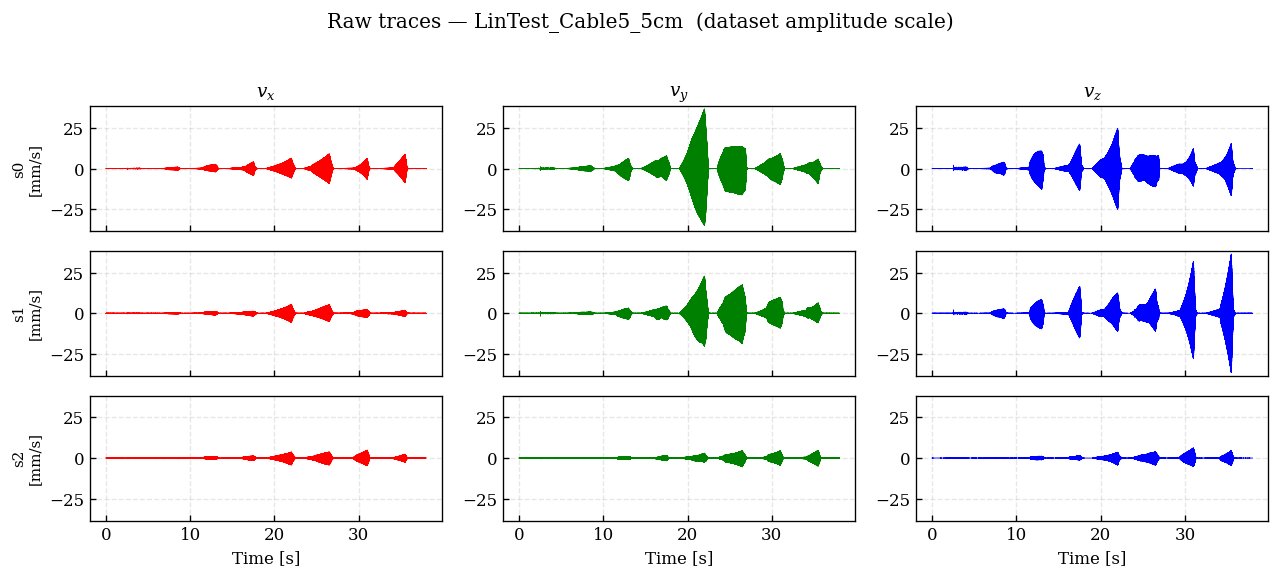

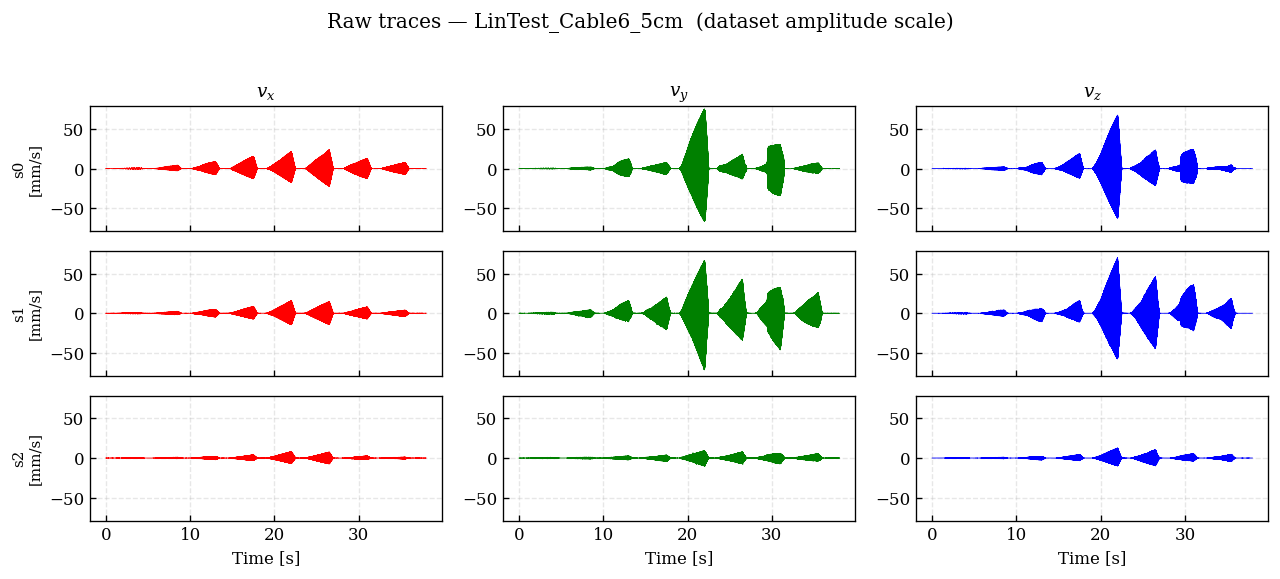

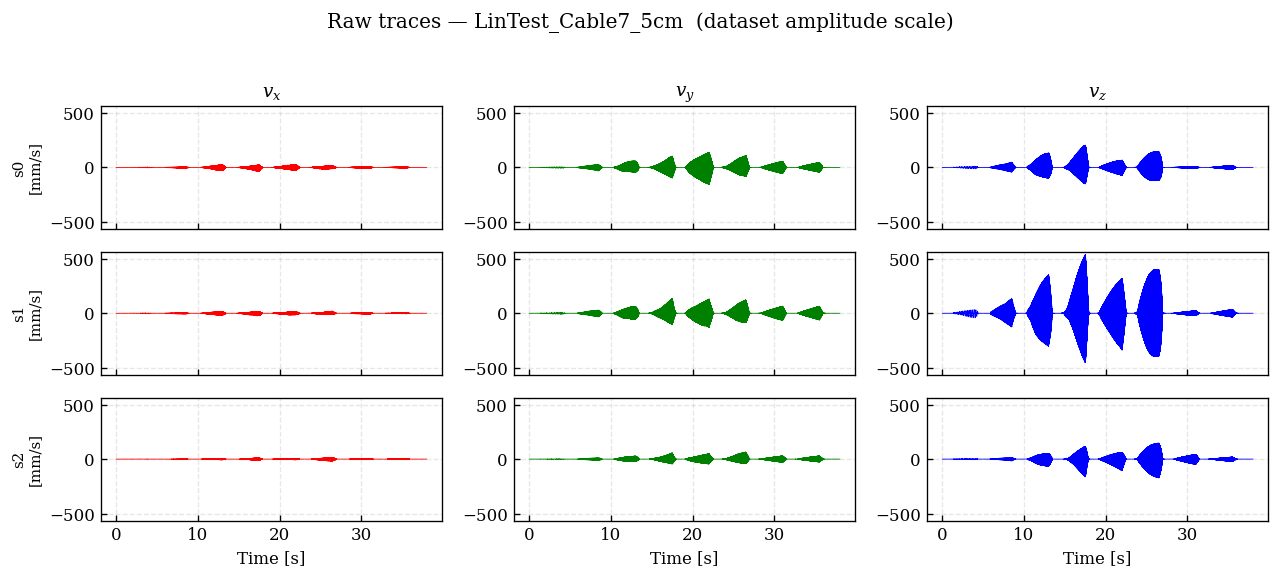

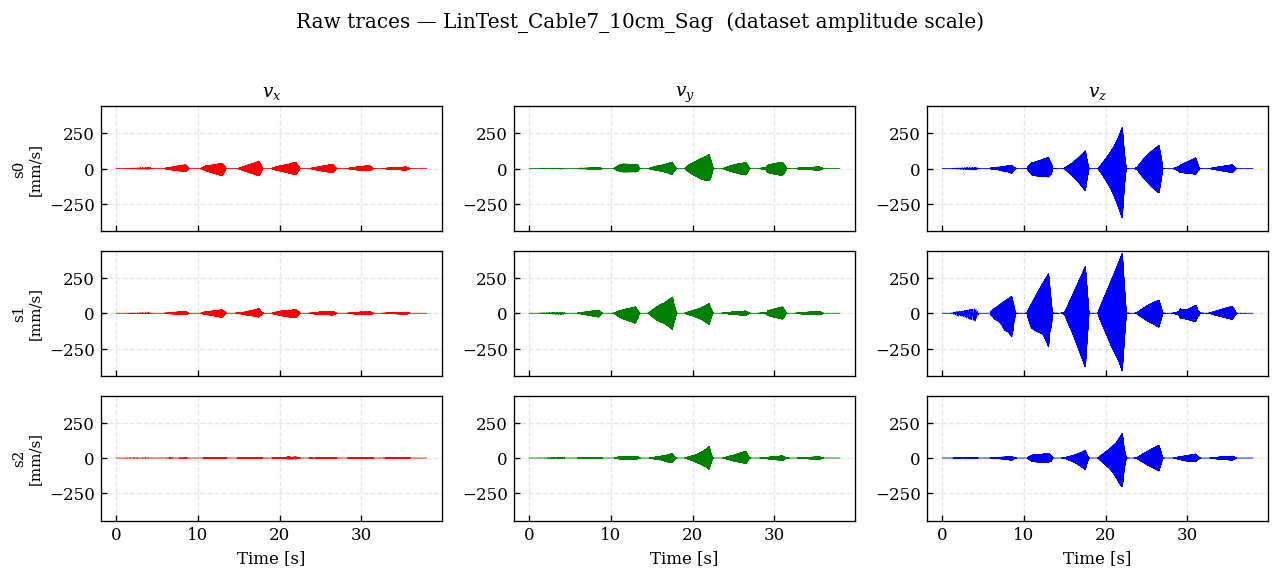

In [3]:
for cfg in DATASETS:
    plotting.plot_raw_traces_uniform(
        cfg, components=('vx', 'vy', 'vz'),
        share_scale='dataset', max_rows=4, title=cfg['label'])

---
## § 3  Run the segment analysis

In [5]:
for cfg in DATASETS:
    print(f"-- {cfg['label']} --")
    analysis.run_linearity_analysis(cfg, frequencies=config.LIN_FREQUENCIES)

-- LinTest_Cable5_5cm --
     5 Hz ... η_med = 0.273
    20 Hz ... η_med = 0.256
    50 Hz ... η_med = 0.251
   100 Hz ... η_med = 0.269
   150 Hz ... η_med = 0.747
   200 Hz ... η_med = 0.358
   300 Hz ... η_med = 0.530
   400 Hz ... η_med = 0.372
-- LinTest_Cable6_5cm --
     5 Hz ... η_med = 0.464
    20 Hz ... η_med = 0.459
    50 Hz ... η_med = 0.438
   100 Hz ... η_med = 0.398
   150 Hz ... η_med = 1.287
   200 Hz ... η_med = 0.510
   300 Hz ... η_med = 0.461
   400 Hz ... η_med = 0.433
-- LinTest_Cable7_5cm --
     5 Hz ... η_med = 0.041
    20 Hz ... η_med = 0.079
    50 Hz ... η_med = 0.143
   100 Hz ... η_med = 0.097
   150 Hz ... η_med = 0.643
   200 Hz ... η_med = 0.105
   300 Hz ... η_med = 0.134
   400 Hz ... η_med = 0.088
-- LinTest_Cable7_10cm_Sag --
     5 Hz ... η_med = 0.144
    20 Hz ... η_med = 0.141
    50 Hz ... η_med = 0.127
   100 Hz ... η_med = 0.056
   150 Hz ... η_med = 0.279
   200 Hz ... η_med = 0.397
   300 Hz ... η_med = 0.258
   400 Hz ... η_med = 0.076

---
## § 4  η(t) and η vs amplitude

Top: η(t), running-median smoothed; grey = fade region; dotted = η_pred.
Bottom: instantaneous |δL| (Hilbert envelope). Then η against |δL| — flat
binned medians = linear coupling; slope or hysteresis = amplitude
dependence.

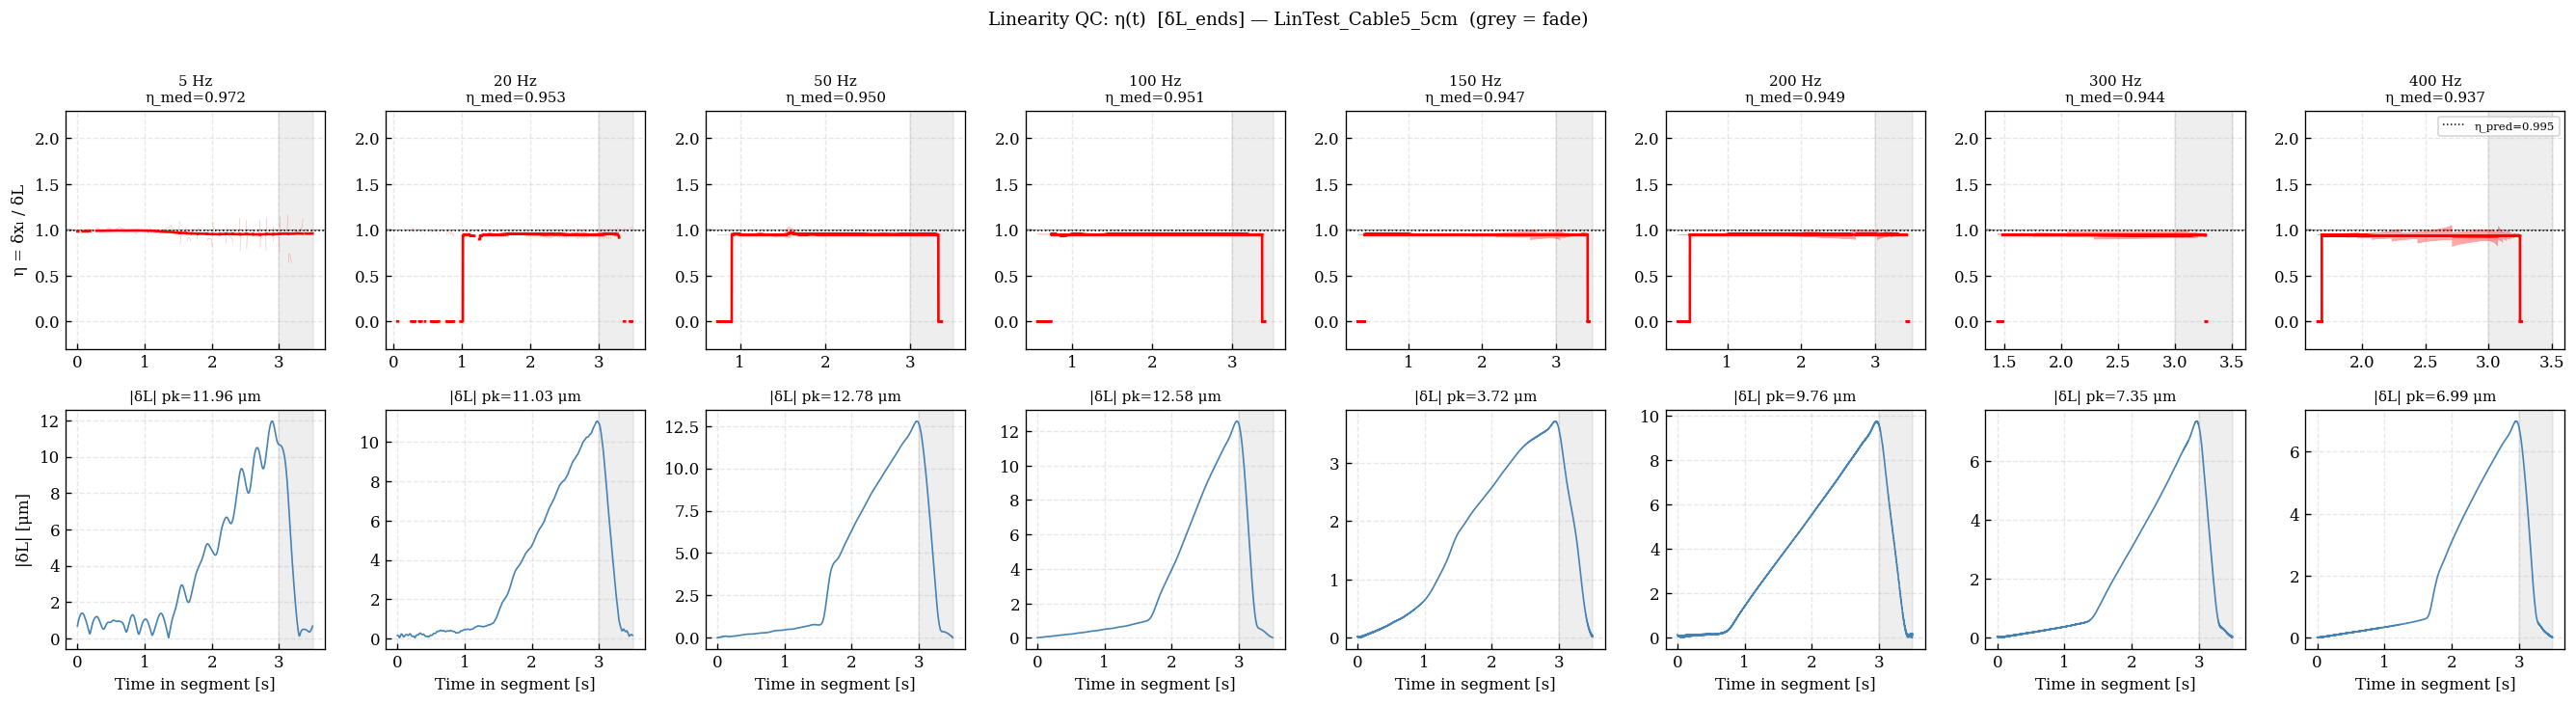

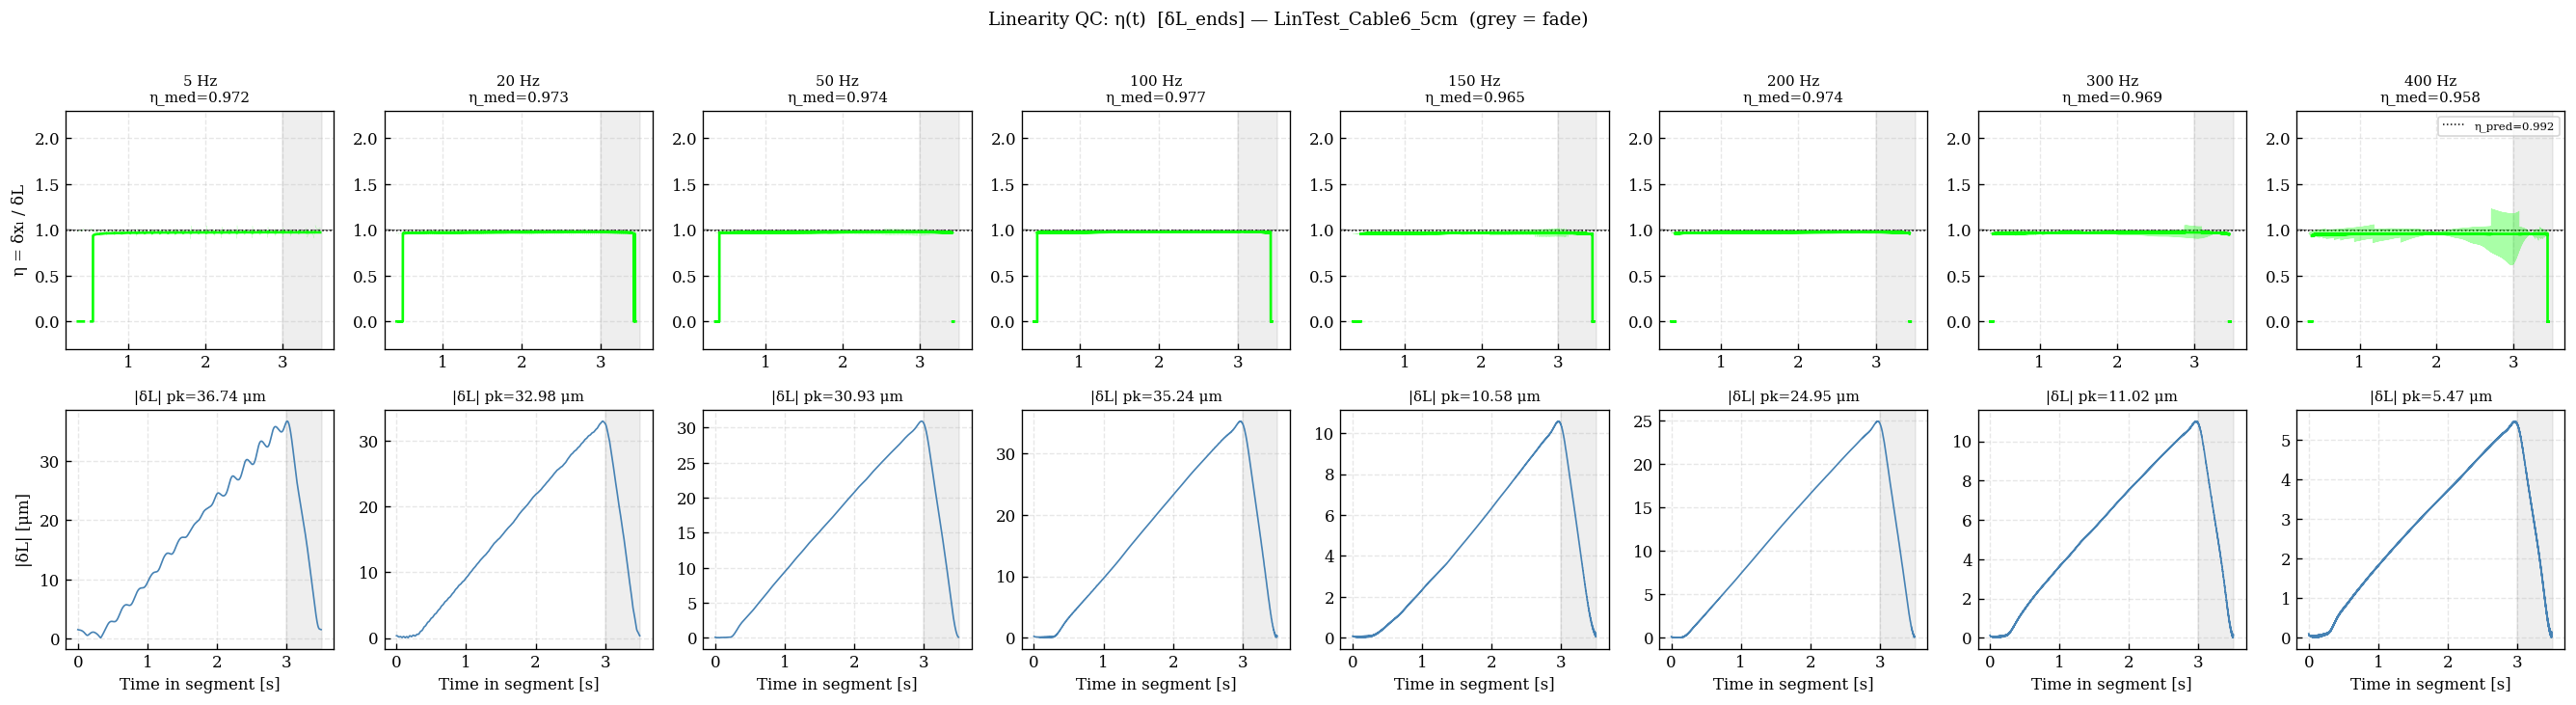

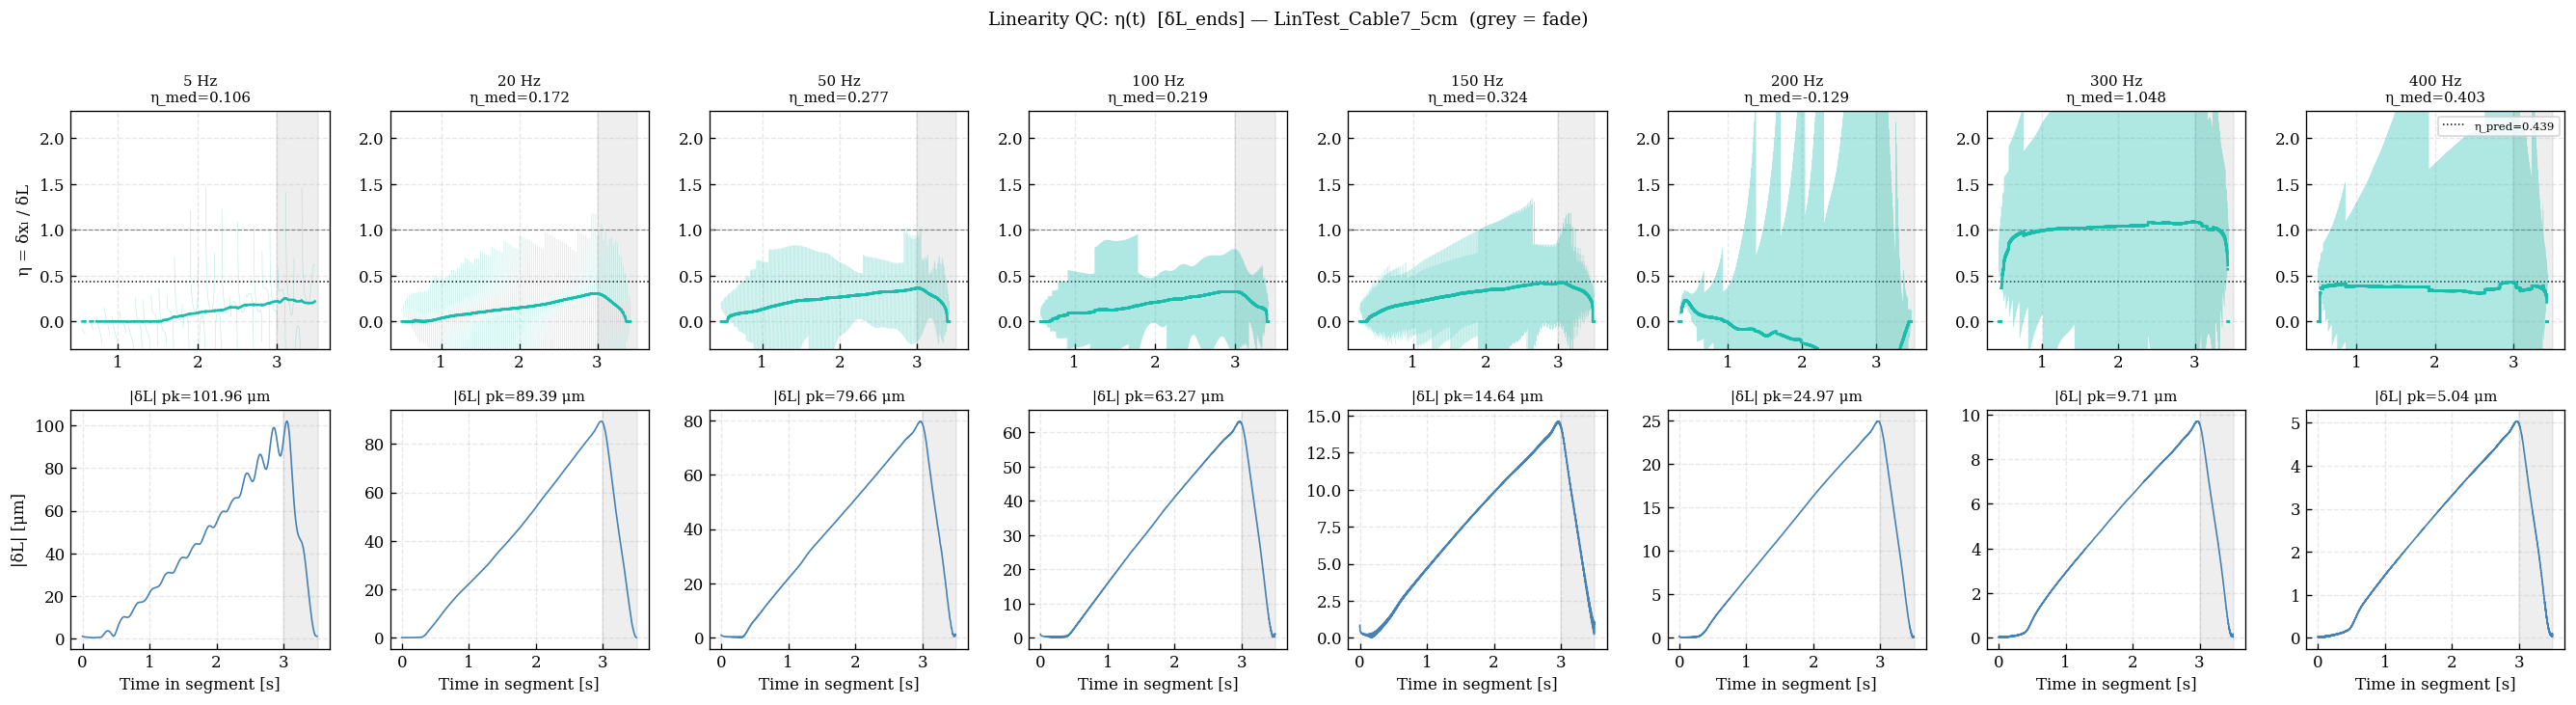

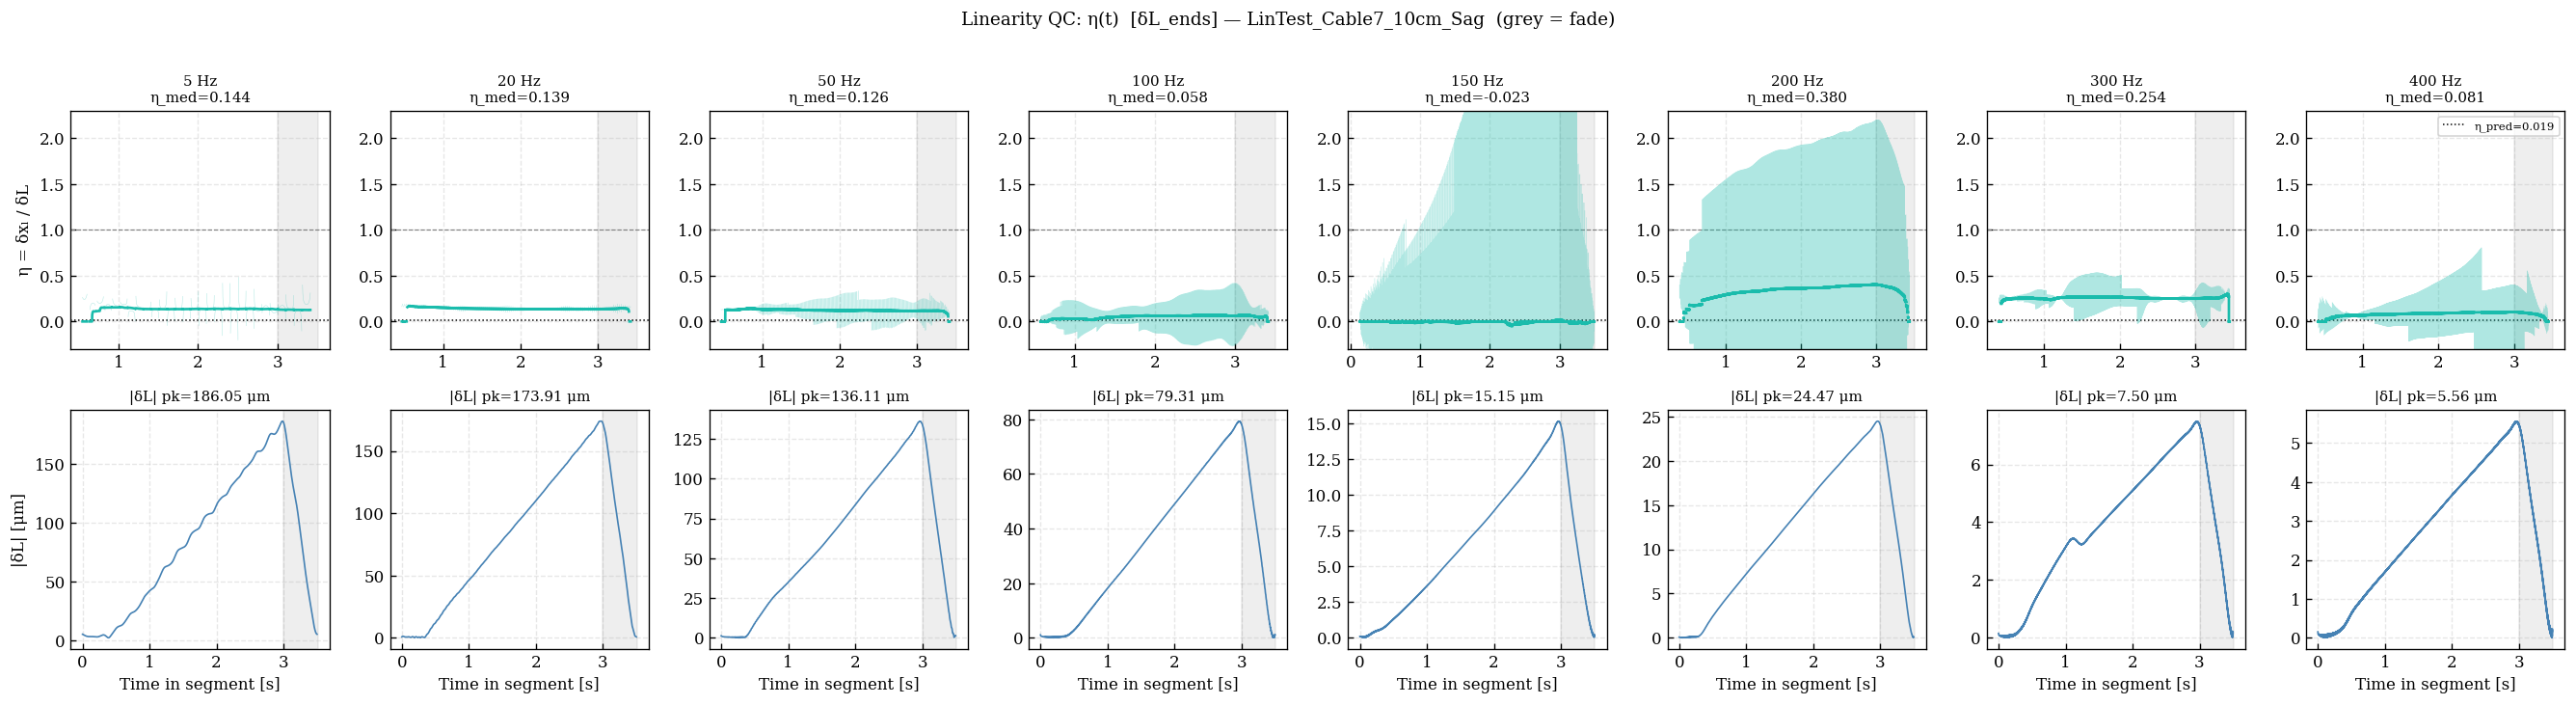

In [6]:
for cfg in DATASETS:
    plotting.plot_linearity_eta_time(cfg, cfg['lin_results'],
                                     smooth_cycles=5, ref='ends')

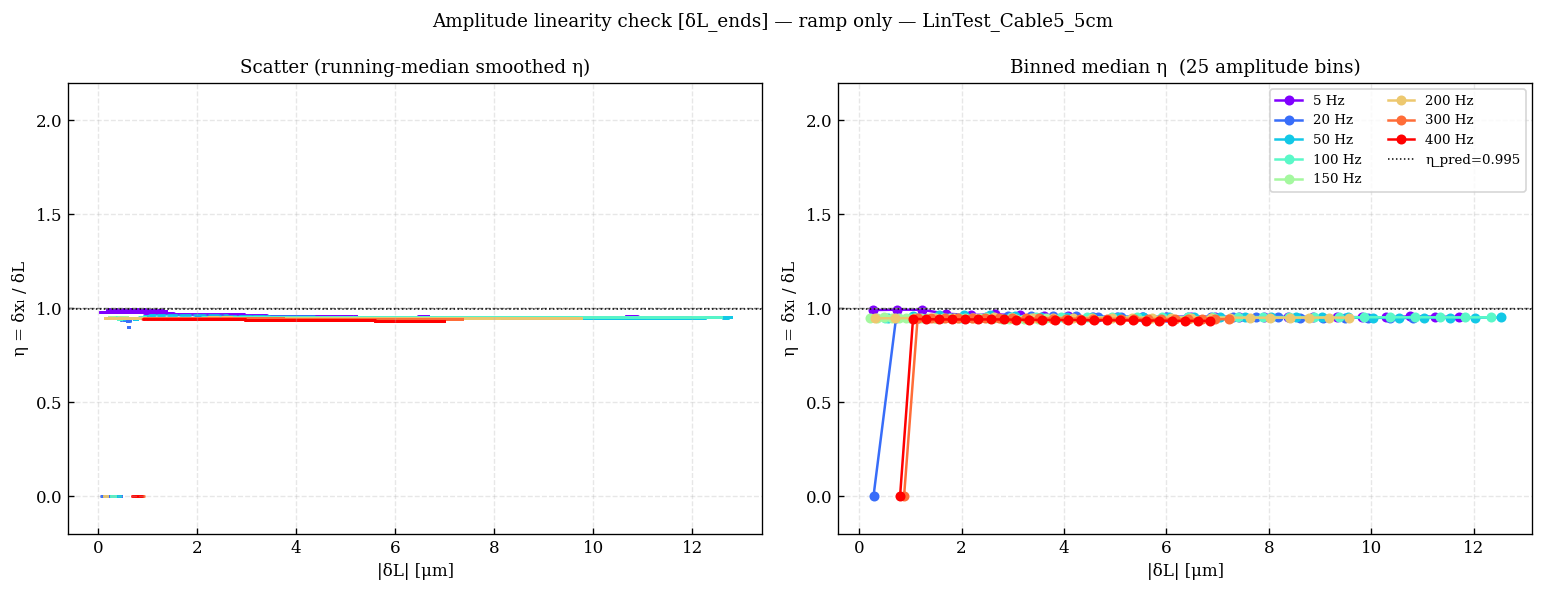

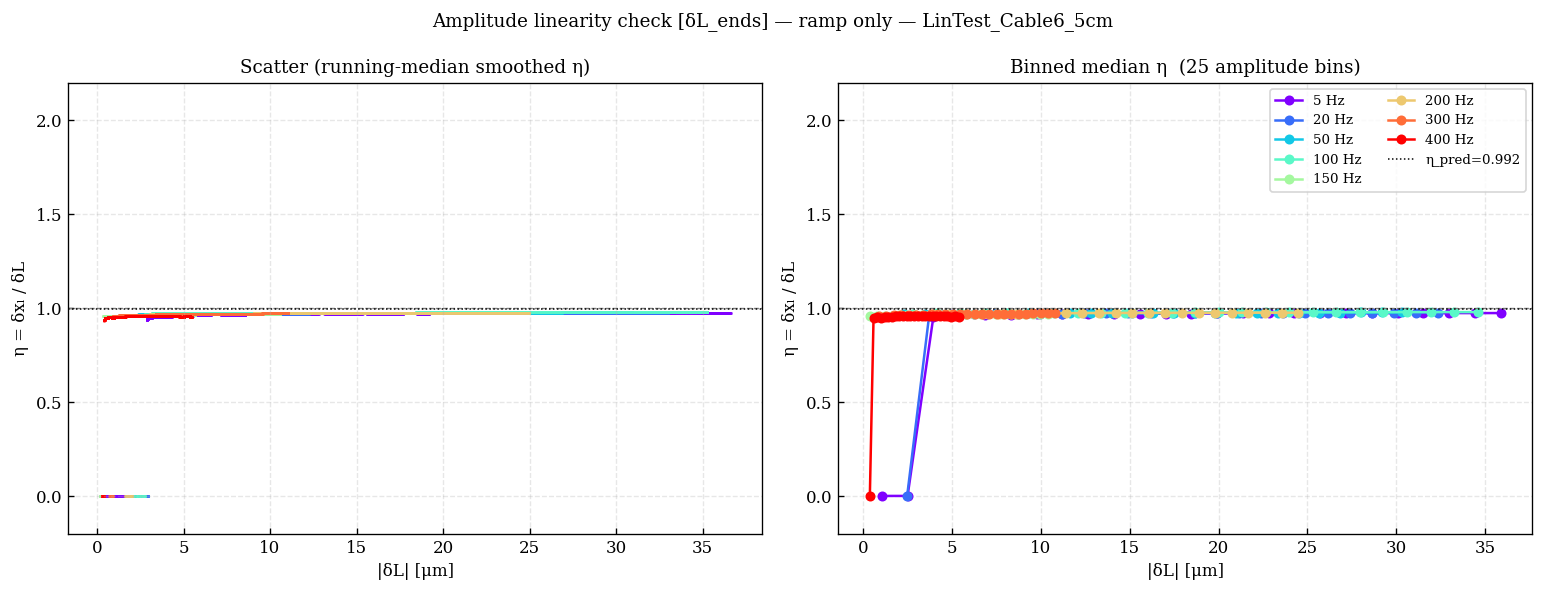

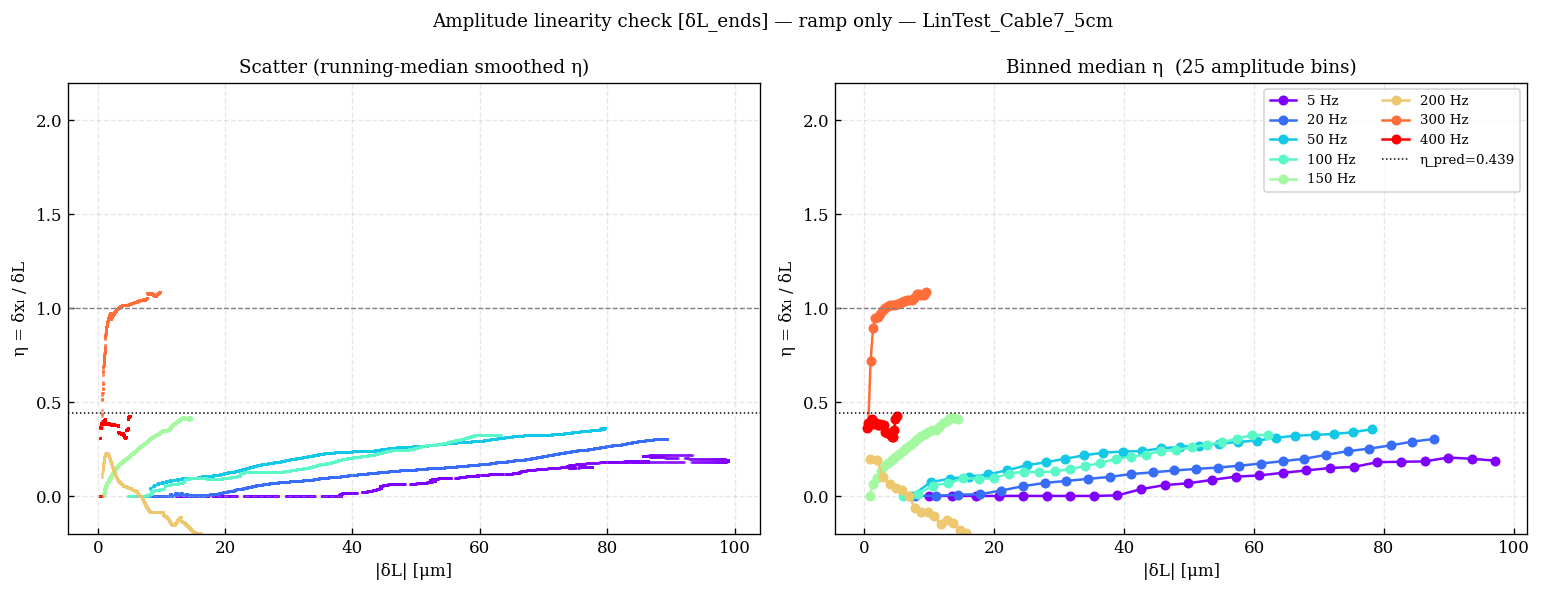

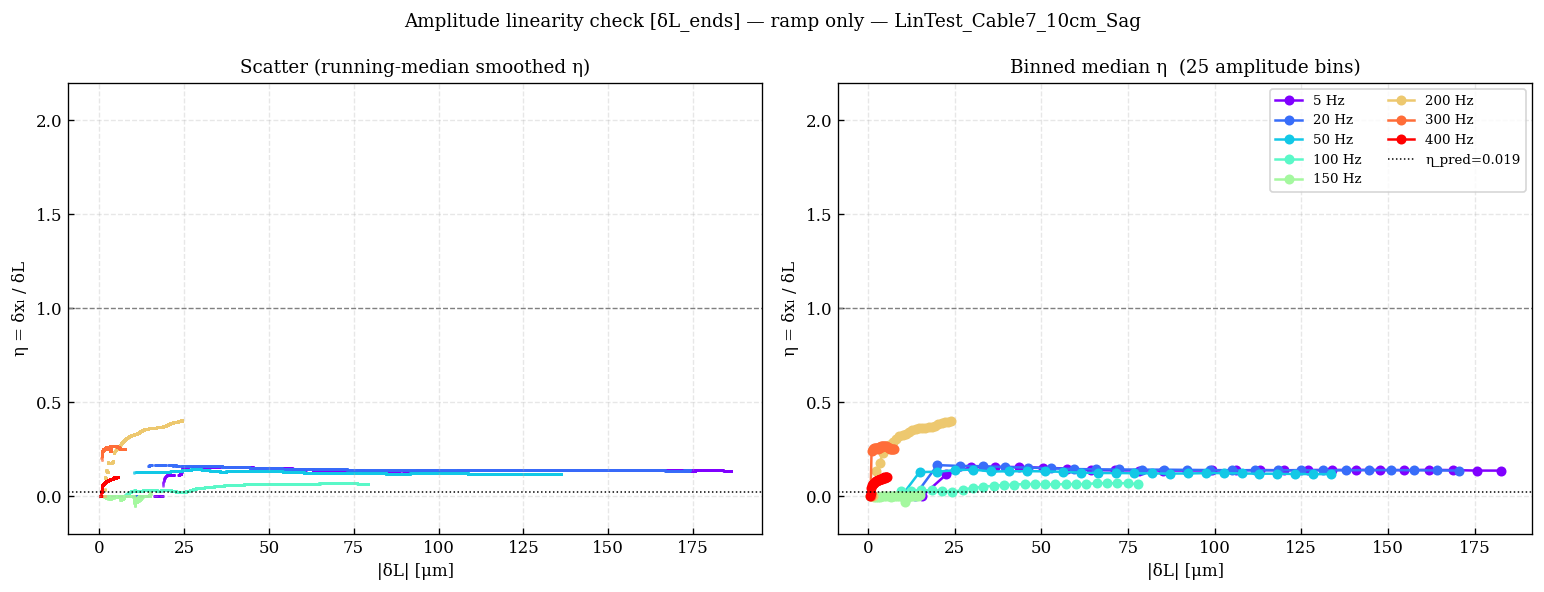

In [7]:
plotting.plot_linearity_eta_vs_amplitude(
    DATASETS, smooth_cycles=5, exclude_fade=True, n_bins=25, ref='ends')

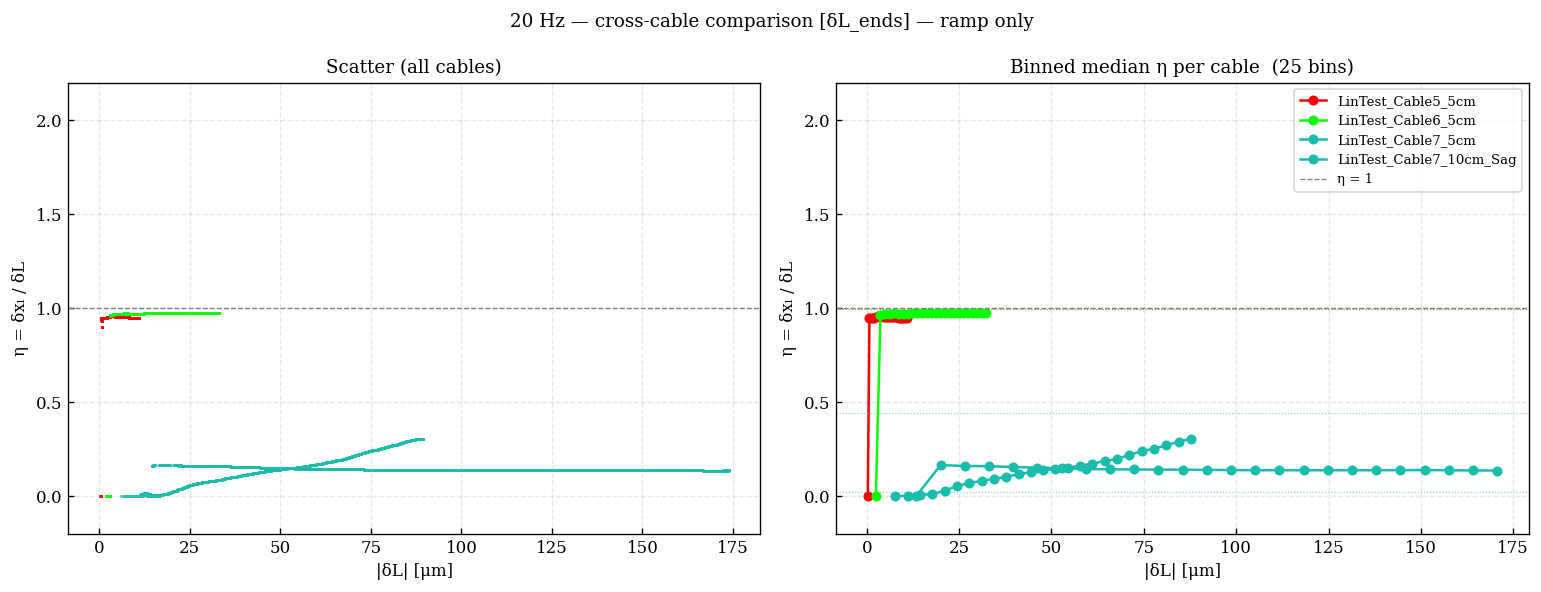

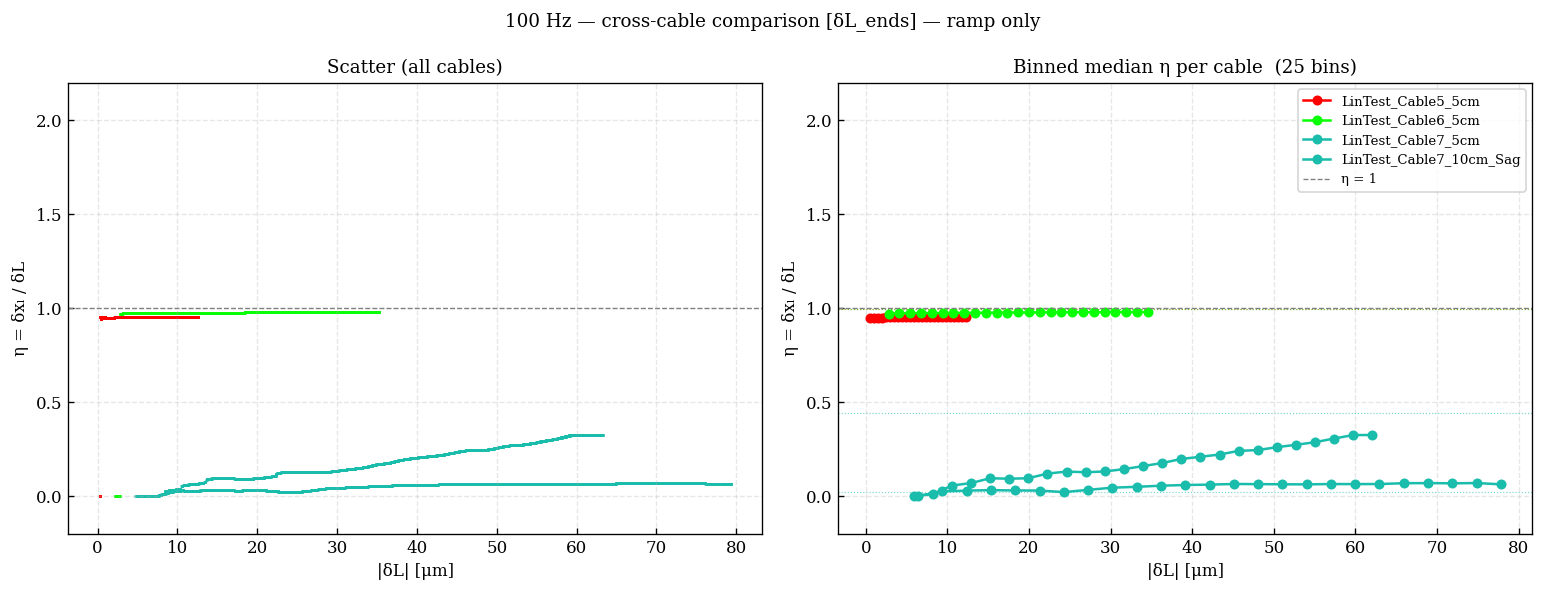

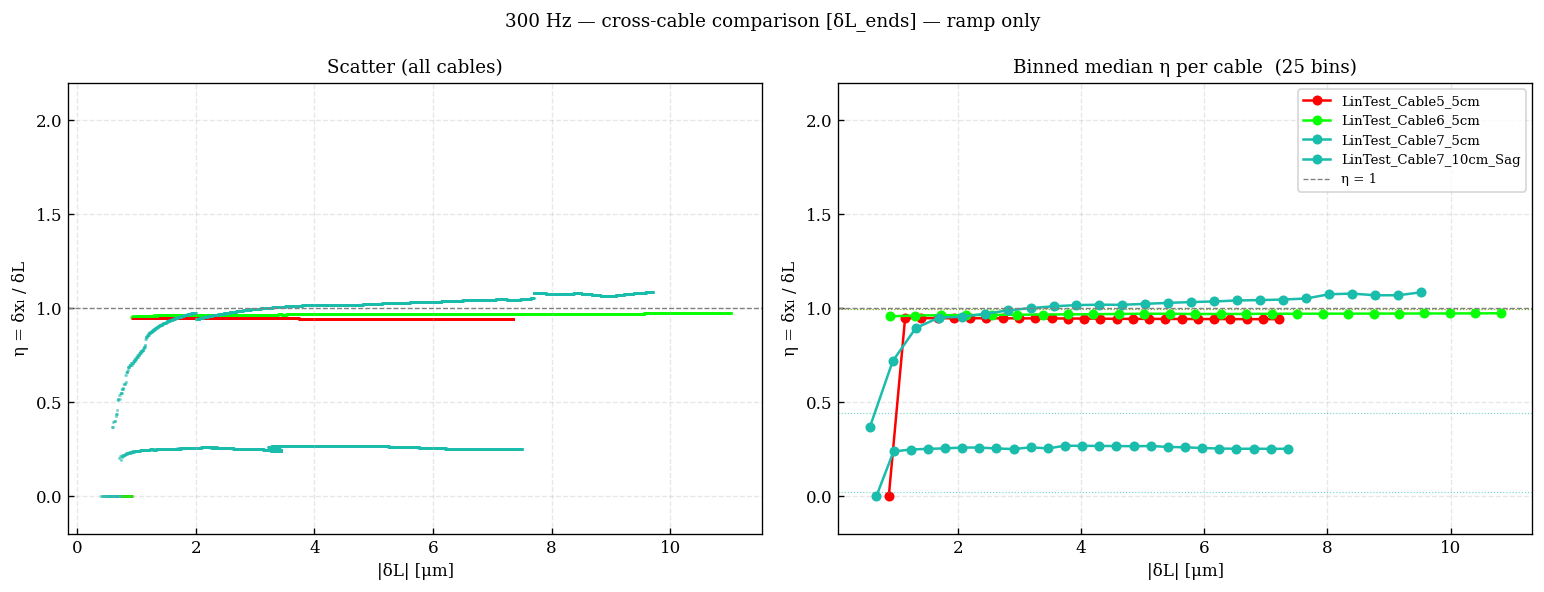

In [8]:
for f_compare in [20, 100, 300]:
    plotting.plot_linearity_comparison(
        DATASETS, f_target=f_compare,
        smooth_cycles=5, exclude_fade=True, ref='ends', n_bins=25)

---
## § 5  Frequency-domain cross-check per segment

For each mono-frequency segment, the Welch H1 FRF between Δu_ends (input) and
δxₗ (output) evaluated at the segment frequency should match the time-domain
median η — a consistency check between the two estimation routes.

In [9]:
from ldv_analysis import freqdomain

rows = []
for cfg in DATASETS:
    for f_t, res in cfg['lin_results'].items():
        fs = cfg['fs']
        f_w, H, coh = freqdomain.welch_transfer(
            res['delta_ends'], res['delta_xl'], fs,
            nperseg=int(fs))                     # 1 s segments -> df = 1 Hz
        k = int(np.argmin(np.abs(f_w - f_t)))
        rows.append(dict(dataset=cfg['label'], f_Hz=f_t,
                         eta_td=round(res['eta_med_ends'], 3),
                         eta_fd=round(float(np.abs(H[k])), 3),
                         coh=round(float(coh[k]), 3)))
pd.DataFrame(rows)

,dataset,f_Hz,eta_td,eta_fd,coh
0,LinTest_Cable5_5cm,5,0.972,0.951,1.000
1,LinTest_Cable5_5cm,20,0.953,0.951,1.000
2,LinTest_Cable5_5cm,50,0.950,0.950,1.000
3,LinTest_Cable5_5cm,100,0.951,0.951,1.000
4,LinTest_Cable5_5cm,150,0.947,0.945,1.000
5,LinTest_Cable5_5cm,200,0.949,0.949,1.000
6,LinTest_Cable5_5cm,300,0.944,0.943,1.000
7,LinTest_Cable5_5cm,400,0.937,0.934,1.000
8,LinTest_Cable6_5cm,5,0.972,0.973,1.000
9,LinTest_Cable6_5cm,20,0.973,0.975,1.000


---
## § 6  Extension vs compression per amplitude bin

`asymmetry.linearity_segment_asymmetry` bins the ramp by instantaneous drive
amplitude and evaluates η separately over extension (δ_ref > 0) and
compression (δ_ref < 0) samples: diverging curves = amplitude-dependent
asymmetry (e.g. slack/slip developing on one half-cycle only).

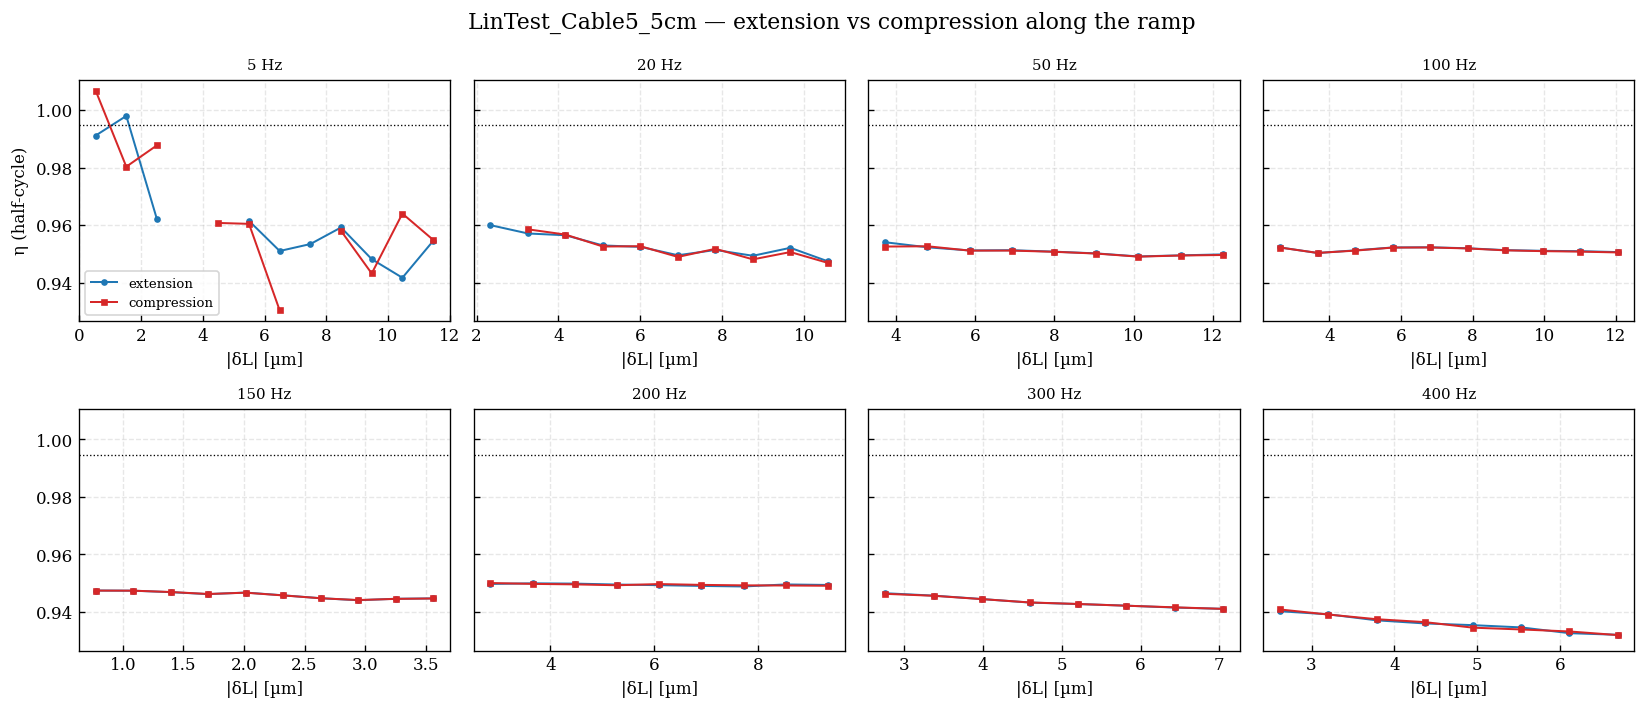

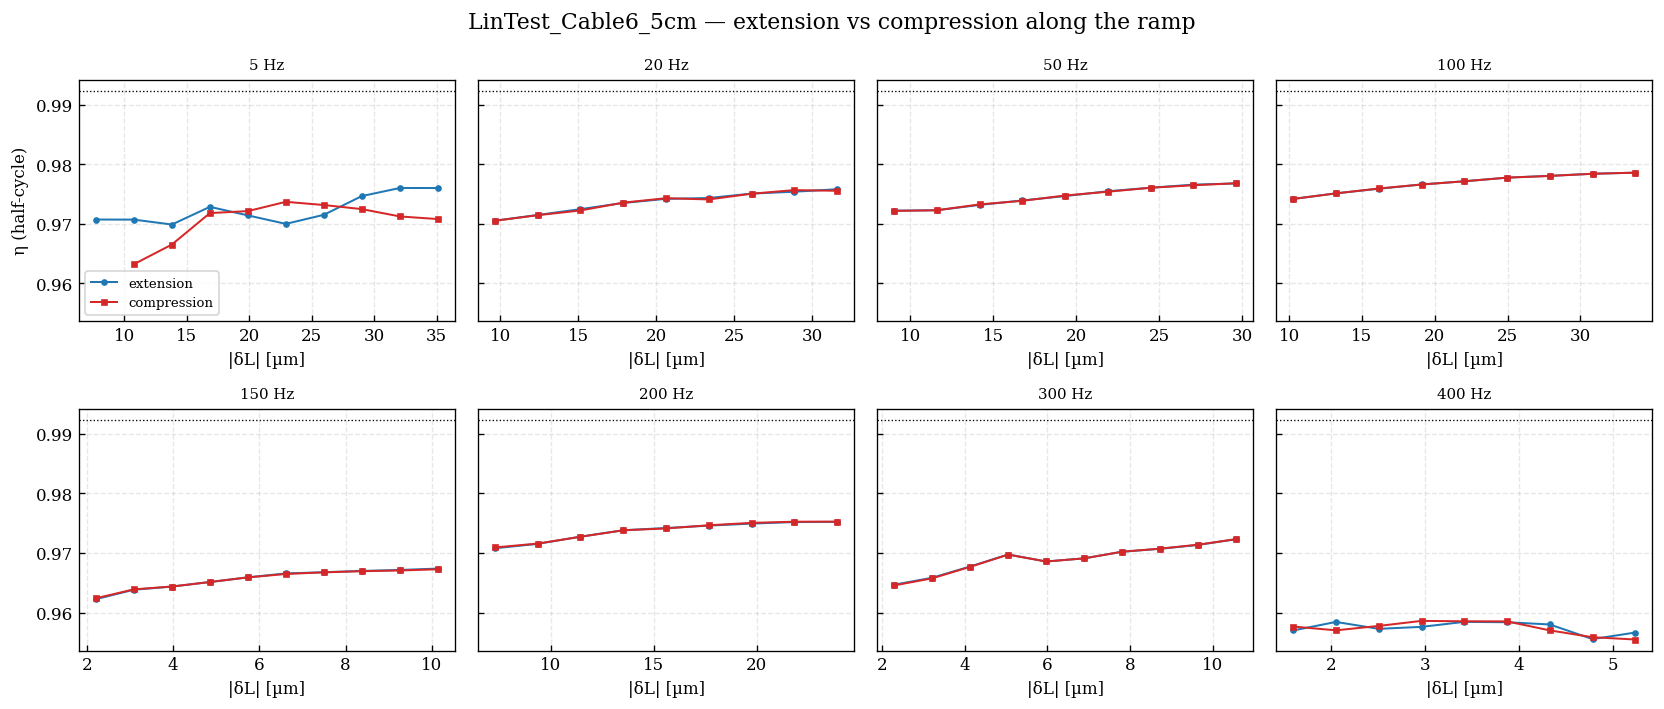

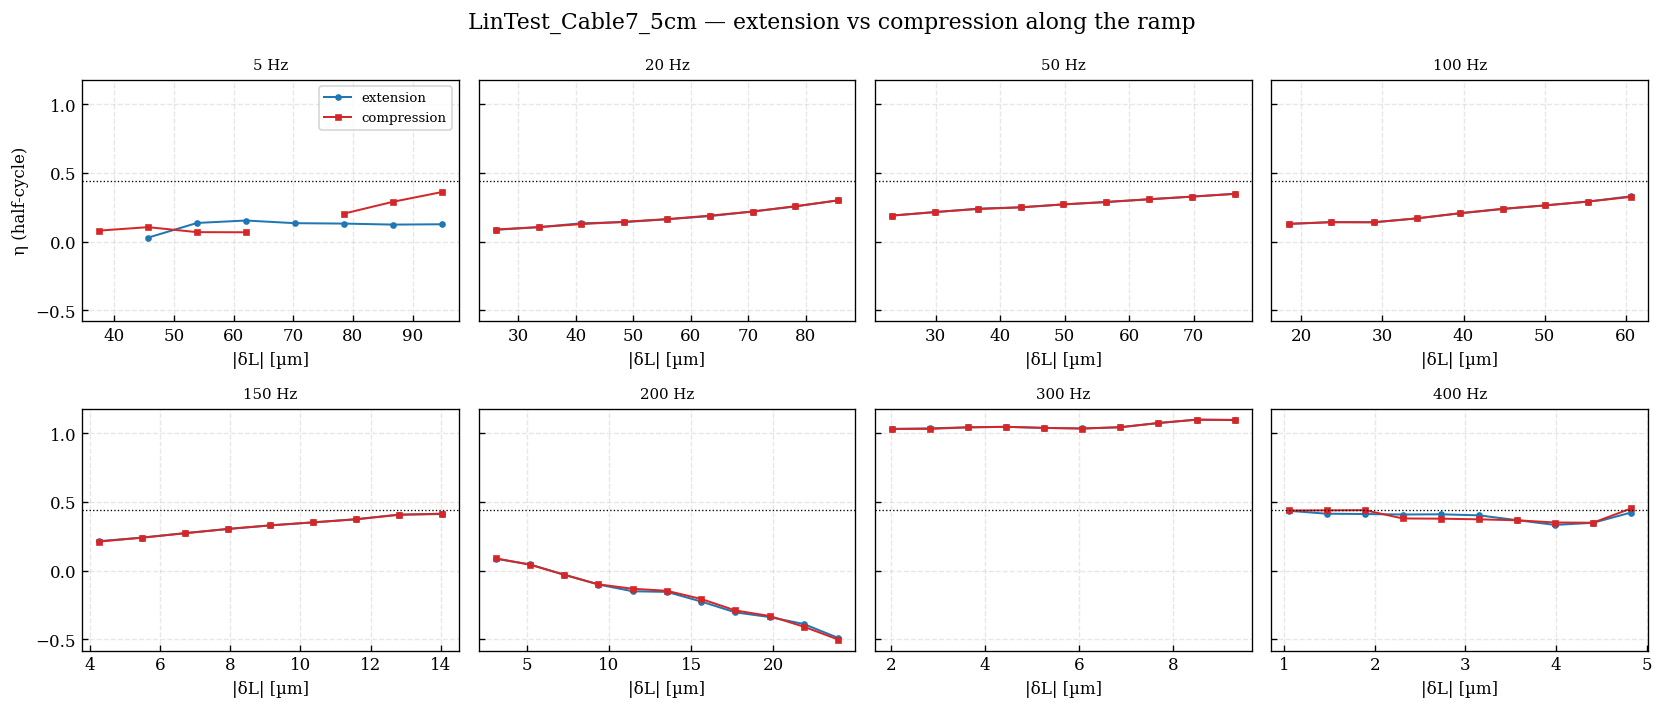

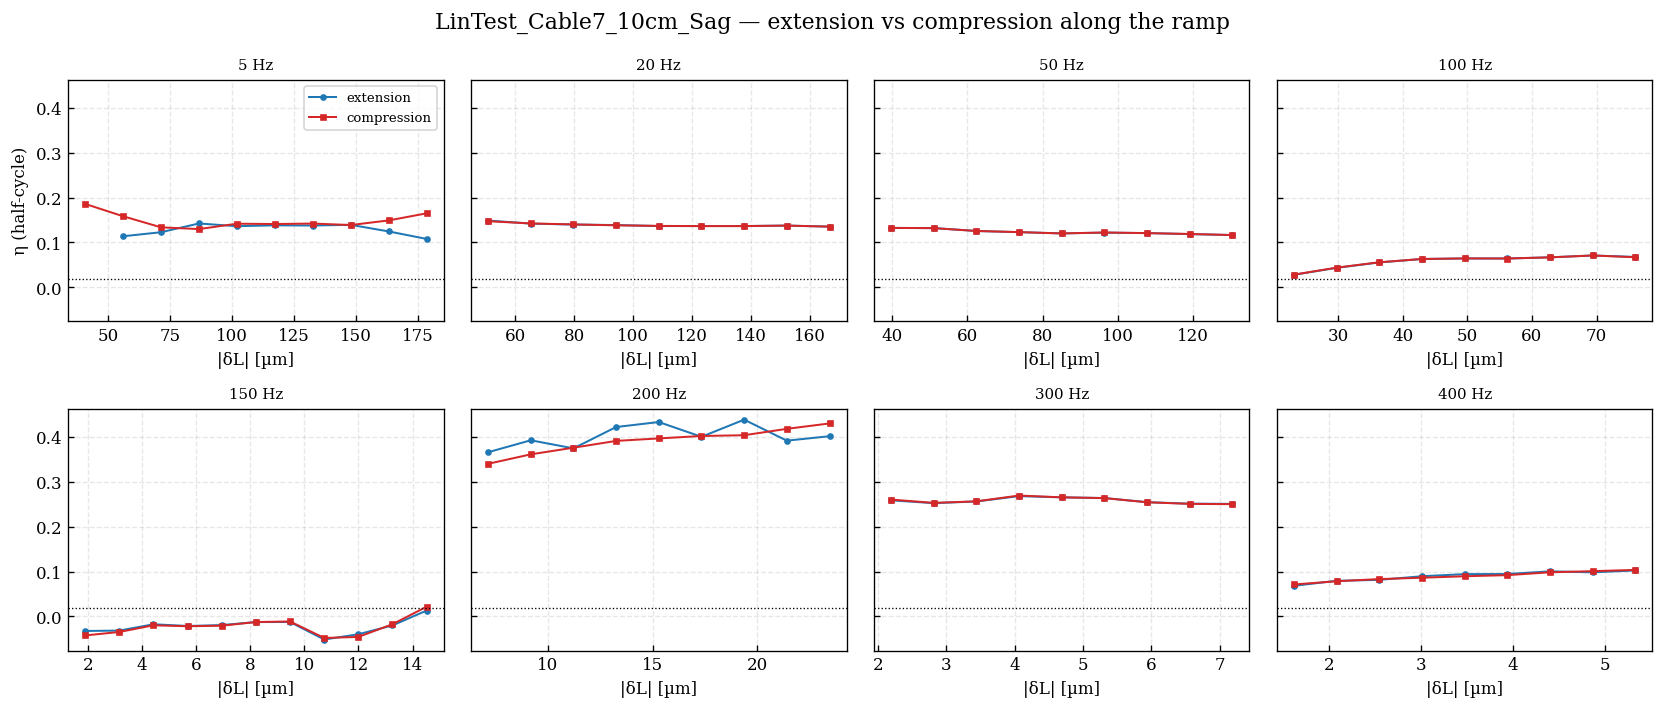

In [10]:
from ldv_analysis import asymmetry

for cfg in DATASETS:
    fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=True)
    for ax, f_t in zip(axes.ravel(), config.LIN_FREQUENCIES):
        d = asymmetry.linearity_segment_asymmetry(cfg, f_t, n_amp_bins=12)
        if d is None:
            ax.set_visible(False)
            continue
        ax.plot(d['amp_centers'] * 1e6, d['eta_ext'], 'o-', ms=3, color='C0',
                label='extension')
        ax.plot(d['amp_centers'] * 1e6, d['eta_comp'], 's-', ms=3, color='C3',
                label='compression')
        ax.axhline(cfg['eta_pred'], color='k', ls=':', lw=0.8)
        ax.set_title(f'{f_t:.0f} Hz', fontsize=9)
        ax.set_xlabel('|δL| [µm]')
    axes[0, 0].set_ylabel('η (half-cycle)')
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"{cfg['label']} — extension vs compression along the ramp")
    plt.tight_layout(); plt.show()

---
## § 7  Interactive dashboards

In [11]:
from ldv_analysis import widgets
widgets.linearity_dashboard(DATASETS, frequencies=config.LIN_FREQUENCIES)

In [12]:
widgets.linearity_slip_dashboard(DATASETS, frequencies=config.LIN_FREQUENCIES)

---
## § 8  Export

In [13]:
acc = dict(labels=[], f=[], eta_med=[], eta_med_ends=[])
for cfg in DATASETS:
    for f_t, res in cfg['lin_results'].items():
        acc['labels'].append(cfg['label'])
        acc['f'].append(f_t)
        acc['eta_med'].append(res['eta_med'])
        acc['eta_med_ends'].append(res['eta_med_ends'])

export.export_results(
    'linearity_eta',
    meta=dict(frequencies=config.LIN_FREQUENCIES,
              segment_s=config.LIN_SEGMENT_DURATION,
              fade_s=config.LIN_FADE_DURATION),
    **acc)

exported linearity_eta.npz: labels(32,), f(32,), eta_med(32,), eta_med_ends(32,)


WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/linearity_eta.npz')